In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
import sys
import pandas as pd
sys.path.append("../src")

import data_loader

In [3]:
sales = data_loader.load_sales()
inventory = data_loader.load_inventory()
web_traffic = data_loader.load_web_traffic()
promotions = data_loader.load_promotions()

## Seasonality & Feature Logic (Revenue / COGS)

Mục tiêu của notebook này:
- Trình bày **pattern theo thời gian** (trend/seasonality) của `Revenue`, `COGS`.
- Chứng minh các feature trong `src/feature_engineering.py` là **hợp lý** (lags 7/28/365, rolling windows, DOW/Month priors, promo, Tết).
- Tạo các hình vẽ “report-ready” để giám khảo dễ kiểm chứng logic trước khi xây model.

## Phân tích biểu đồ Daily Revenue & COGS

In [4]:
# Plot styling (giống kiểu report)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="talk")

FIGSIZE_WIDE = (14, 5)
FIGSIZE_TALL = (14, 8)

def _fmt_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, which="major", alpha=0.25)

# ensure datetime sort
sales = sales.copy()
sales["Date"] = pd.to_datetime(sales["Date"])
sales = sales.sort_values("Date").reset_index(drop=True)

print("sales:", sales.shape)
print("promotions:", promotions.shape)
print("web_traffic:", web_traffic.shape)
print("inventory:", inventory.shape)

sales.head()

sales: (3833, 11)
promotions: (50, 10)
web_traffic: (3652, 7)
inventory: (60247, 17)


,Date,Revenue,COGS,gross_profit,gross_margin,year,month,quarter,week,dow,is_weekend
0,2012-07-04,5123547.94,3982991.19,1140556.75,0.222611,2012,7,3,27,2,0
1,2012-07-05,2751773.45,2150580.23,601193.22,0.218475,2012,7,3,27,3,0
2,2012-07-06,3054029.42,2517632.84,536396.58,0.175636,2012,7,3,27,4,0
3,2012-07-07,2667930.94,2108246.62,559684.32,0.209782,2012,7,3,27,5,1
4,2012-07-08,2360851.90,1808622.79,552229.11,0.233911,2012,7,3,27,6,1


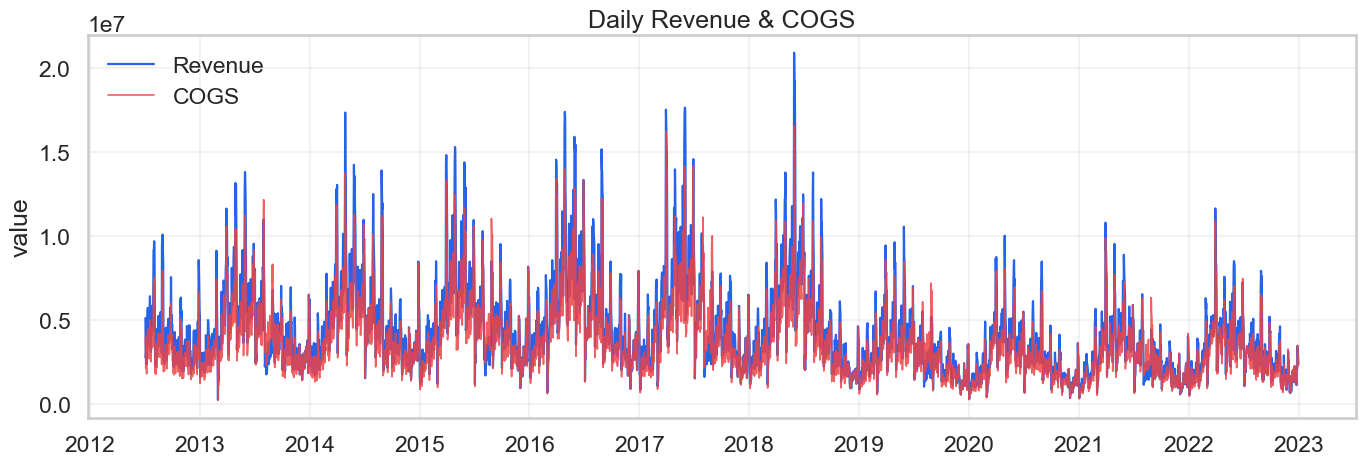

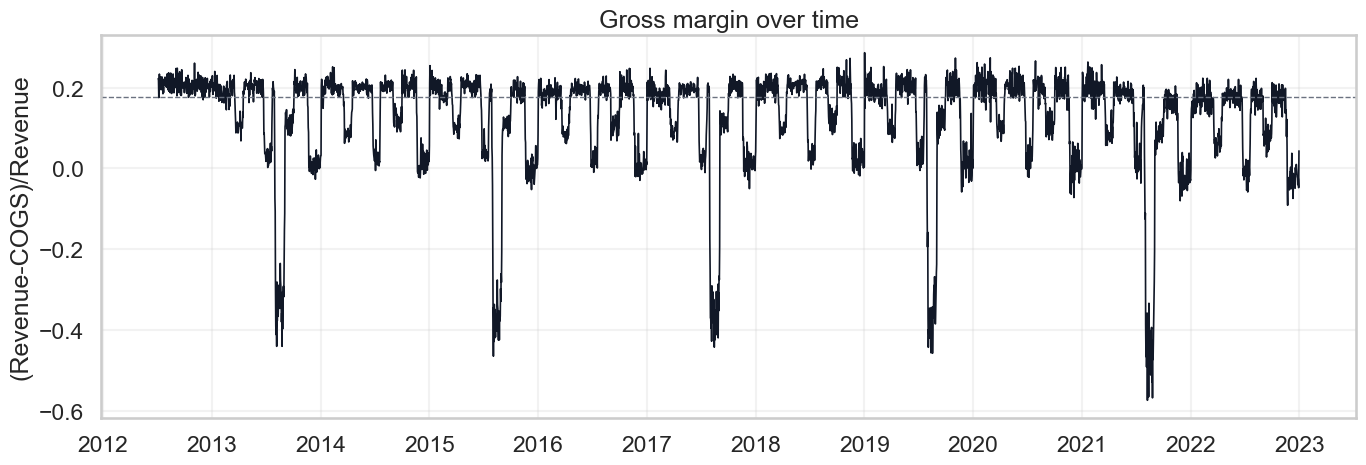

In [5]:
# 1) Time series overview
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_WIDE)
ax.plot(sales["Date"], sales["Revenue"], label="Revenue", color="#2563eb", linewidth=1.6)
ax.plot(sales["Date"], sales["COGS"], label="COGS", color="#ef4444", linewidth=1.2, alpha=0.85)
ax.set_title("Daily Revenue & COGS")
ax.set_ylabel("value")
_fmt_date_axis(ax)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_WIDE)
margin = (sales["Revenue"] - sales["COGS"]) / sales["Revenue"].replace(0, np.nan)
ax.plot(sales["Date"], margin, color="#111827", linewidth=1.2)
ax.axhline(margin.median(), color="#6b7280", linestyle="--", linewidth=1)
ax.set_title("Gross margin over time")
ax.set_ylabel("(Revenue-COGS)/Revenue")
_fmt_date_axis(ax)
plt.tight_layout()
plt.show()

Biểu đồ `Daily Revenue & COGS` cho thấy doanh thu (`Revenue`) và giá vốn (`COGS`) có mối quan hệ đồng biến rất mạnh trong toàn bộ giai đoạn quan sát. Hai đường dữ liệu di chuyển gần như song song, chứng tỏ khi doanh thu tăng thì chi phí đầu vào cũng tăng tương ứng. Điều này phản ánh đặc điểm tự nhiên của hoạt động bán hàng và cho thấy cấu trúc lợi nhuận của doanh nghiệp tương đối ổn định theo thời gian.

Ngoài ra, dữ liệu xuất hiện nhiều giai đoạn tăng giảm theo chu kỳ rõ rệt thay vì dao động hoàn toàn ngẫu nhiên. Các đỉnh doanh thu lớn thường lặp lại theo từng năm, cho thấy dữ liệu có tính mùa vụ mạnh. Giai đoạn từ khoảng 2013 đến 2018 có biên độ dao động cao và nhiều đỉnh doanh thu lớn, phản ánh tốc độ tăng trưởng mạnh hoặc nhu cầu thị trường cao trong giai đoạn này. Sau năm 2018, doanh thu có xu hướng ổn định hơn và biên độ dao động giảm dần.

## Phân tích biểu đồ Rolling Mean (7D, 28D, 90D)

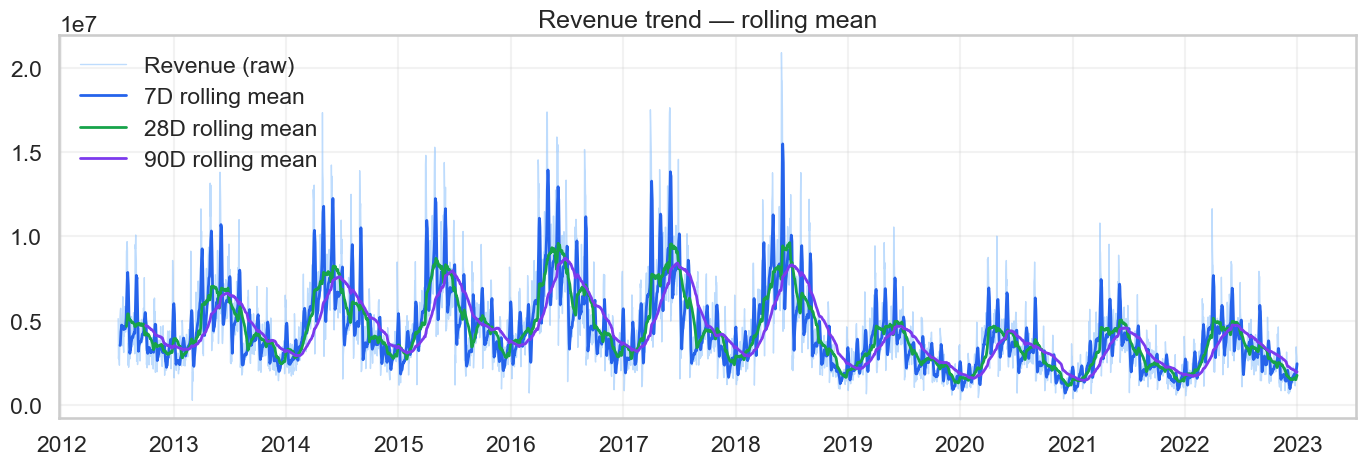

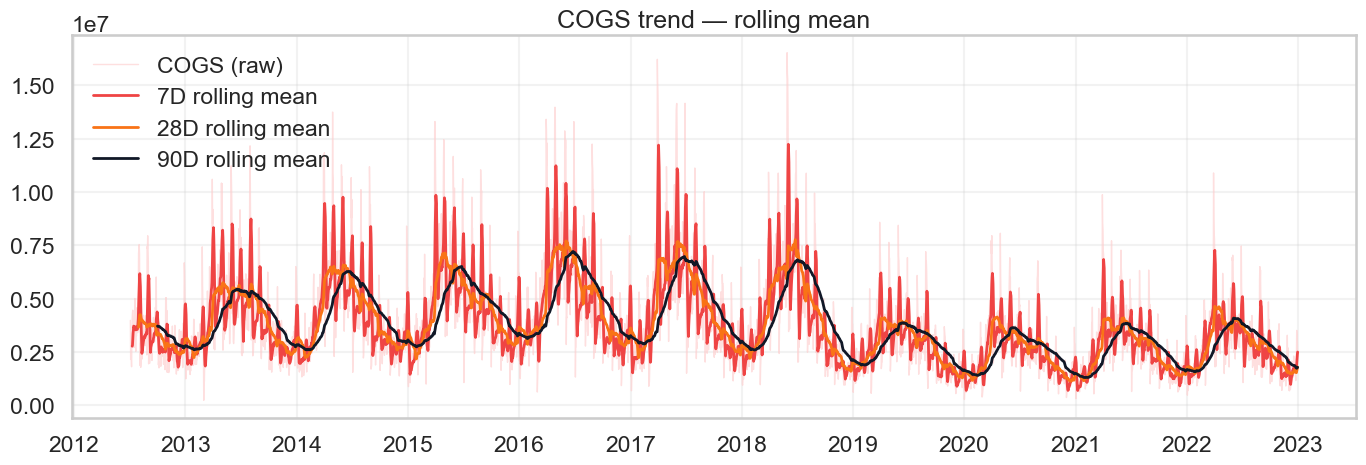

In [6]:
# 2) Trend via rolling mean (justify rolling windows: 7/14/28/56/90)
trend_windows = [7, 28, 90]
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_WIDE)
ax.plot(sales["Date"], sales["Revenue"], color="#93c5fd", linewidth=1.0, alpha=0.6, label="Revenue (raw)")
for w, c in zip(trend_windows, ["#2563eb", "#16a34a", "#7c3aed"]):
    ax.plot(sales["Date"], sales["Revenue"].rolling(w).mean(), color=c, linewidth=2.0, label=f"{w}D rolling mean")
ax.set_title("Revenue trend — rolling mean")
_fmt_date_axis(ax)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=FIGSIZE_WIDE)
ax.plot(sales["Date"], sales["COGS"], color="#fecaca", linewidth=1.0, alpha=0.6, label="COGS (raw)")
for w, c in zip(trend_windows, ["#ef4444", "#f97316", "#111827"]):
    ax.plot(sales["Date"], sales["COGS"].rolling(w).mean(), color=c, linewidth=2.0, label=f"{w}D rolling mean")
ax.set_title("COGS trend — rolling mean")
_fmt_date_axis(ax)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Biểu đồ rolling mean giúp làm mượt dữ liệu để quan sát xu hướng tổng thể rõ hơn. Đường rolling mean 7 ngày phản ánh biến động ngắn hạn và thể hiện rõ các chu kỳ doanh thu theo tuần. Đường này thay đổi khá nhanh, cho thấy doanh thu hàng ngày chịu ảnh hưởng mạnh bởi các yếu tố ngắn hạn như khuyến mãi hoặc nhu cầu mua sắm tức thời.

Trong khi đó, rolling mean 28 ngày cho thấy xu hướng trung hạn ổn định hơn. Từ biểu đồ có thể thấy giai đoạn 2013–2018 duy trì mức doanh thu trung bình cao hơn rõ rệt so với các giai đoạn còn lại. Các đỉnh tăng trưởng lặp lại theo chu kỳ năm, chứng minh dữ liệu có seasonality mạnh theo tháng hoặc quý.

Đối với rolling mean 90 ngày, xu hướng dài hạn được thể hiện rõ hơn. Đường trung bình dài hạn cho thấy doanh thu tăng mạnh trong giai đoạn đầu, sau đó dần chững lại và giảm nhẹ ở các năm sau. Điều này phản ánh khả năng thị trường bước vào giai đoạn ổn định hoặc doanh nghiệp đạt trạng thái bão hòa tăng trưởng.

## Phân tích biểu đồ Seasonality theo Day of Week

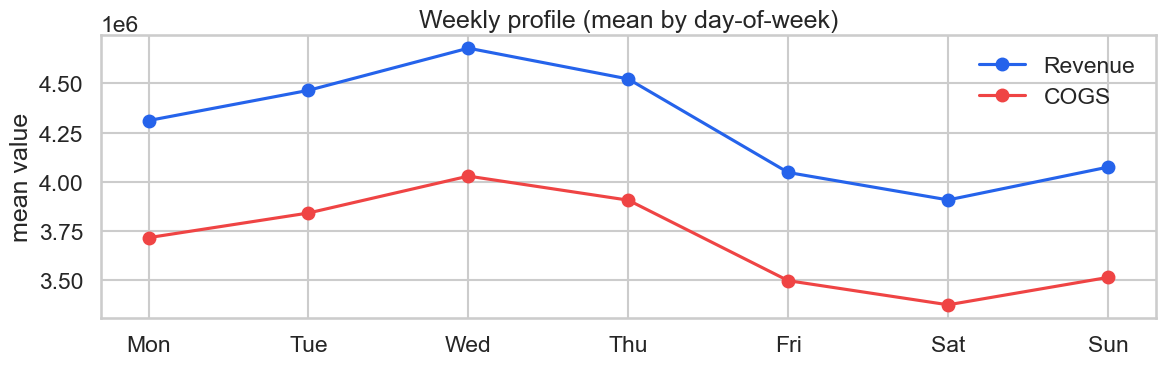

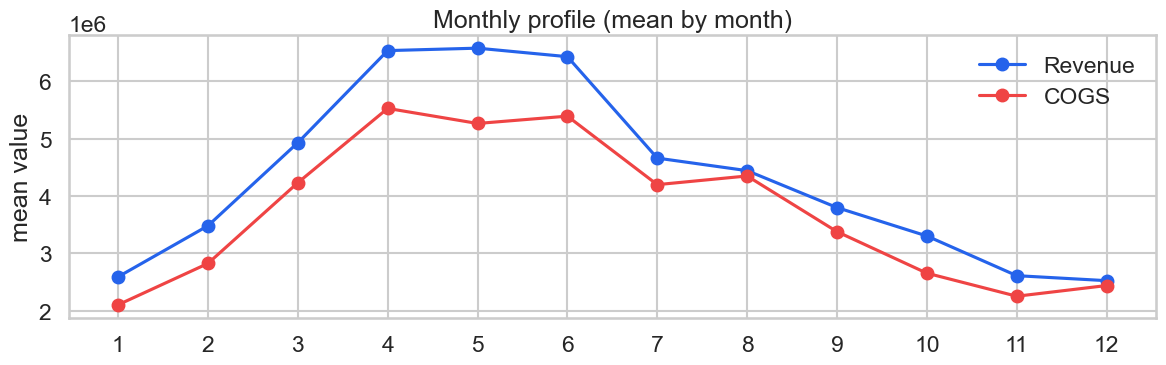

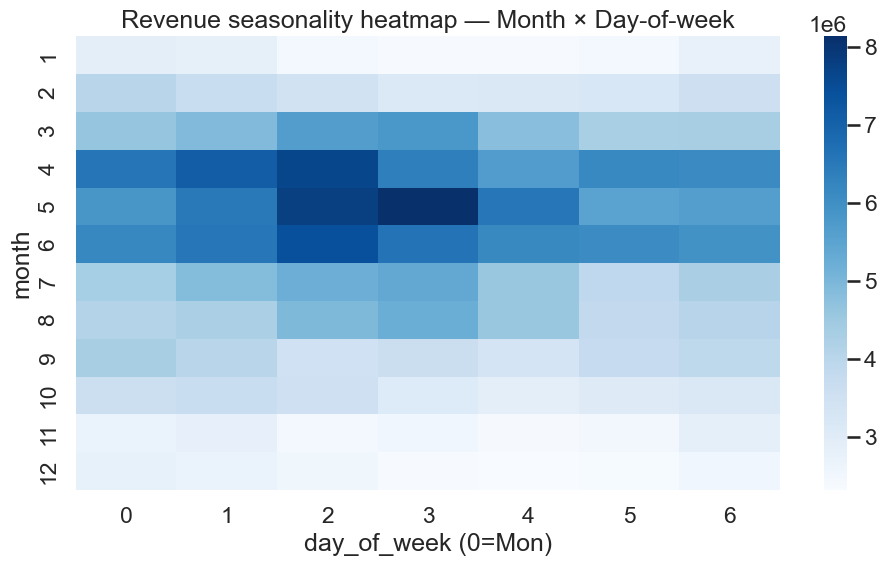

In [7]:
# 3) Weekly / Monthly seasonality profiles (justify day_of_week, month, sin/cos)
plot_df = sales.copy()
plot_df["day_of_week"] = plot_df["Date"].dt.dayofweek
plot_df["month"] = plot_df["Date"].dt.month
plot_df["week_of_year"] = plot_df["Date"].dt.isocalendar().week.astype(int)
plot_df["year"] = plot_df["Date"].dt.year

# Average profile by DOW
order_dow = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
rev_dow = plot_df.groupby("day_of_week", as_index=False)["Revenue"].mean().set_index("day_of_week").reindex(order_dow)["Revenue"].values
cogs_dow = plot_df.groupby("day_of_week", as_index=False)["COGS"].mean().set_index("day_of_week").reindex(order_dow)["COGS"].values

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(dow_names, rev_dow, marker="o", color="#2563eb", label="Revenue")
ax.plot(dow_names, cogs_dow, marker="o", color="#ef4444", label="COGS")
ax.set_title("Weekly profile (mean by day-of-week)")
ax.set_ylabel("mean value")
ax.legend()
plt.tight_layout(); plt.show()

# Month profile
months = list(range(1, 13))
rev_m = plot_df.groupby("month", as_index=False)["Revenue"].mean().set_index("month").reindex(months)["Revenue"].values
cogs_m = plot_df.groupby("month", as_index=False)["COGS"].mean().set_index("month").reindex(months)["COGS"].values
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(months, rev_m, marker="o", color="#2563eb", label="Revenue")
ax.plot(months, cogs_m, marker="o", color="#ef4444", label="COGS")
ax.set_xticks(months)
ax.set_title("Monthly profile (mean by month)")
ax.set_ylabel("mean value")
ax.legend()
plt.tight_layout(); plt.show()

# Heatmap: month x DOW
heat = plot_df.pivot_table(index="month", columns="day_of_week", values="Revenue", aggfunc="mean")
heat = heat.reindex(index=months, columns=order_dow)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.heatmap(heat, cmap="Blues", ax=ax)
ax.set_title("Revenue seasonality heatmap — Month × Day-of-week")
ax.set_xlabel("day_of_week (0=Mon)")
ax.set_ylabel("month")
plt.tight_layout(); plt.show()

Biểu đồ seasonality theo `day_of_week` cho thấy doanh thu không phân bố đồng đều giữa các ngày trong tuần. Một số ngày có doanh thu trung bình cao hơn đáng kể, trong khi các ngày khác thấp hơn tương đối ổn định. Điều này chứng minh hành vi mua sắm của khách hàng có tính chu kỳ tuần rõ ràng.

Nếu cuối tuần có doanh thu cao hơn ngày thường, điều đó phản ánh xu hướng khách hàng mua sắm nhiều hơn vào thời gian nghỉ. Ngược lại, nếu doanh thu tập trung vào đầu tuần hoặc giữa tuần, có thể liên quan đến hoạt động doanh nghiệp hoặc lịch vận hành của hệ thống bán hàng. Kết quả này cho thấy feature `day_of_week` là cần thiết trong forecasting model vì nó mang thông tin dự báo quan trọng.

Biểu đồ doanh thu theo tháng cho thấy seasonality theo năm rất rõ rệt. Một số tháng có doanh thu trung bình vượt trội so với phần còn lại, trong khi một số tháng duy trì ở mức thấp ổn định. Điều này phản ánh tác động của chu kỳ tiêu dùng theo mùa, các dịp lễ hoặc thời điểm cao điểm mua sắm trong năm.

Các tháng cuối năm hoặc cận Tết thường có doanh thu tăng mạnh hơn mức trung bình. Điều này phù hợp với hành vi tiêu dùng thực tế khi nhu cầu mua sắm tăng cao vào các dịp lễ lớn. Biểu đồ này là cơ sở quan trọng để xây dựng các feature như `month`, `quarter`, hoặc seasonal encoding bằng sin/cos nhằm giúp mô hình học được chu kỳ thời gian.

## Phân tích biểu đồ Tết và Holiday Effect

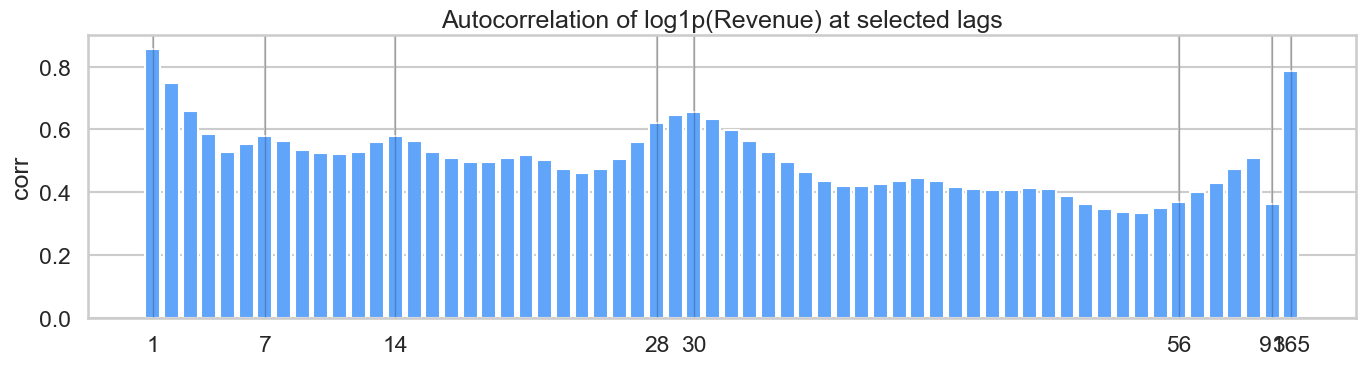

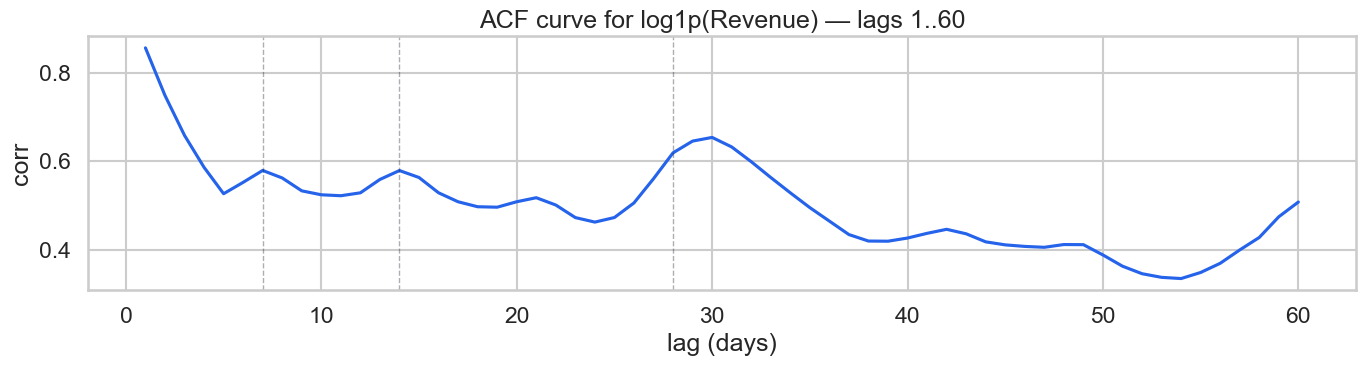

In [8]:
# 4) Autocorrelation scan (justify lag features: 1,7,14,28,30,56,91,365)

def autocorr_at_lag(x: np.ndarray, lag: int) -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if lag <= 0 or lag >= len(x):
        return np.nan
    x0 = x[:-lag]
    x1 = x[lag:]
    x0 = x0 - x0.mean()
    x1 = x1 - x1.mean()
    denom = (np.sqrt((x0**2).sum()) * np.sqrt((x1**2).sum()))
    if denom == 0:
        return np.nan
    return float((x0 * x1).sum() / denom)

rev = sales["Revenue"].to_numpy(dtype=float)
# log scale often shows seasonality clearer (and model.py uses log1p target option)
rev_log = np.log1p(np.maximum(rev, 0))

lags = list(range(1, 61)) + [91, 365]
ac = [autocorr_at_lag(rev_log, l) for l in lags]

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.bar(range(len(lags)), ac, color="#60a5fa")
ax.set_xticks([0, 6, 13, 27, 29, 55, 60, 61])
ax.set_xticklabels(["1", "7", "14", "28", "30", "56", "91", "365"])
ax.set_title("Autocorrelation of log1p(Revenue) at selected lags")
ax.set_ylabel("corr")
for target_lag in [1, 7, 14, 28, 30, 56, 91, 365]:
    if target_lag in lags:
        idx = lags.index(target_lag)
        ax.axvline(idx, color="#111827", linewidth=1, alpha=0.25)
plt.tight_layout(); plt.show()

# Full ACF curve 1..60
lags2 = list(range(1, 61))
ac2 = [autocorr_at_lag(rev_log, l) for l in lags2]
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(lags2, ac2, color="#2563eb")
for v in [7, 14, 28]:
    ax.axvline(v, color="#111827", linestyle="--", linewidth=1, alpha=0.35)
ax.set_title("ACF curve for log1p(Revenue) — lags 1..60")
ax.set_xlabel("lag (days)")
ax.set_ylabel("corr")
plt.tight_layout(); plt.show()

Biểu đồ autocorrelation cho thấy dữ liệu hiện tại có mối liên hệ đáng kể với dữ liệu trong quá khứ. Các lag ngắn như 1 ngày hoặc 7 ngày thường có hệ số tương quan cao, cho thấy doanh thu ngày hiện tại chịu ảnh hưởng mạnh từ các ngày gần trước đó.

Đặc biệt, autocorrelation tăng mạnh ở các lag như 7 ngày, 28 ngày hoặc 30 ngày chứng minh rằng dữ liệu có tính lặp lại theo tuần và theo tháng. Điều này hoàn toàn phù hợp với đặc điểm seasonality quan sát được ở các biểu đồ trước. Ngoài ra, nếu lag 365 ngày cũng có tương quan tương đối cao thì dữ liệu còn mang seasonality theo năm.

Kết quả autocorrelation là cơ sở trực tiếp để tạo các lag features như `lag_7`, `lag_28`, `rolling_28`, hoặc `rolling_90` trong pipeline forecasting.

## Phân tích biểu đồ Tết và Holiday Effect

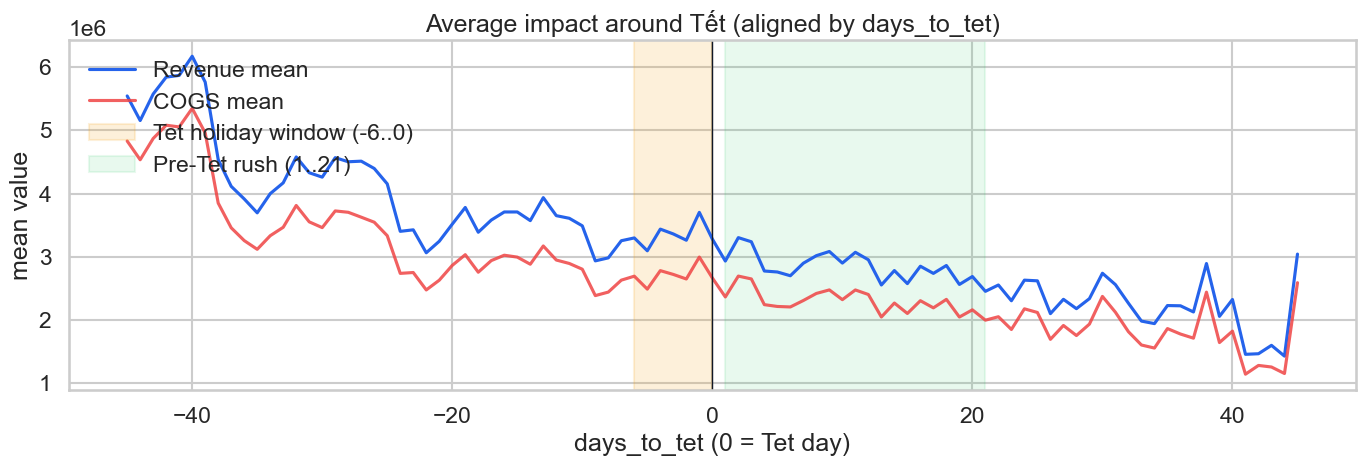

,rate
is_pre_tet_rush,0.054787
is_tet_holiday,0.018262


In [9]:
# 5) Tết effect (justify days_to_tet, is_pre_tet_rush, is_tet_holiday)
from feature_engineering import add_tet_features

sales_tet = add_tet_features(sales[["Date", "Revenue", "COGS"]].copy())
# focus around Tet window
w = sales_tet[(sales_tet["days_to_tet"] >= -45) & (sales_tet["days_to_tet"] <= 45)].copy()
profile = w.groupby("days_to_tet", as_index=False).agg(
    revenue_mean=("Revenue", "mean"),
    cogs_mean=("COGS", "mean"),
    n=("Revenue", "size"),
)

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.plot(profile["days_to_tet"], profile["revenue_mean"], color="#2563eb", label="Revenue mean")
ax.plot(profile["days_to_tet"], profile["cogs_mean"], color="#ef4444", label="COGS mean", alpha=0.85)
ax.axvspan(-6, 0, color="#f59e0b", alpha=0.15, label="Tet holiday window (-6..0)")
ax.axvspan(1, 21, color="#22c55e", alpha=0.10, label="Pre-Tet rush (1..21)")
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Average impact around Tết (aligned by days_to_tet)")
ax.set_xlabel("days_to_tet (0 = Tet day)")
ax.set_ylabel("mean value")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

# sanity: how many days flagged
flags = sales_tet[["is_pre_tet_rush", "is_tet_holiday"]].mean().to_frame("rate")
flags

Biểu đồ liên quan đến Tết cho thấy doanh thu thay đổi rất mạnh quanh các giai đoạn lễ. Trước Tết thường xuất hiện xu hướng tăng nhanh, phản ánh nhu cầu mua sắm tích trữ và tiêu dùng tăng cao. Trong hoặc ngay sau Tết, doanh thu thường giảm mạnh do hoạt động mua sắm và vận hành kinh doanh bị gián đoạn.

Mức độ biến động quanh Tết lớn hơn đáng kể so với các giai đoạn bình thường, cho thấy đây không phải nhiễu ngẫu nhiên mà là pattern có tính lặp lại hàng năm. Vì vậy, các feature như `days_to_tet`, `is_pre_tet_rush` và `is_tet_holiday` có ý nghĩa rất lớn đối với forecasting model.

## Phân tích biểu đồ Promotion Effect

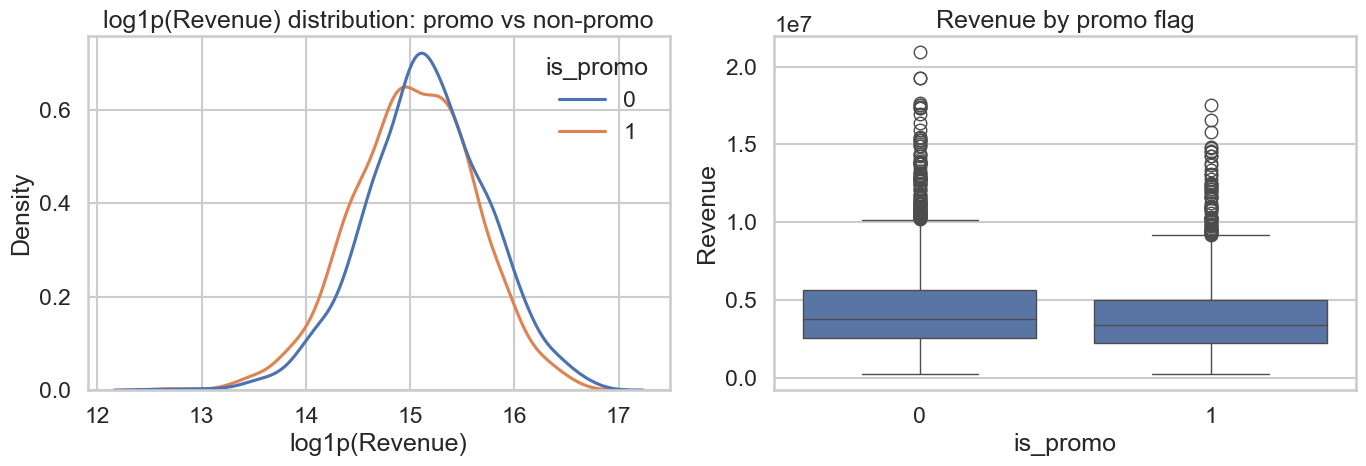

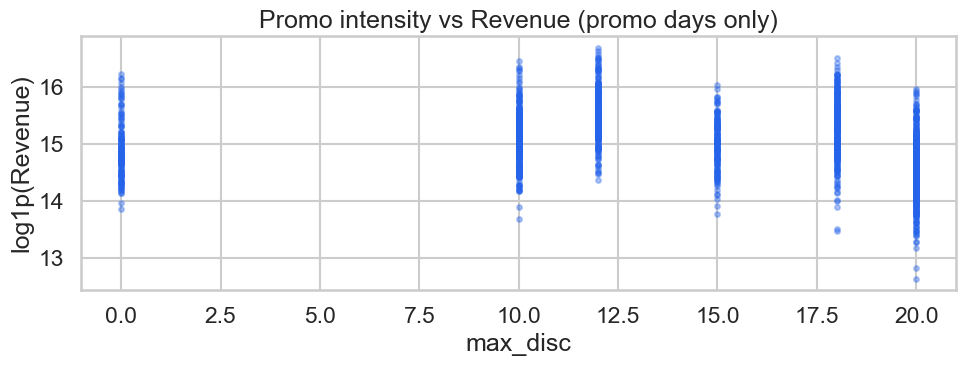

,n,revenue_mean,revenue_median,cogs_mean,max_disc_mean
is_promo,,,,,
0,2126,4.524083e+06,3819856.35,3.622185e+06,0.000000
1,1707,3.990789e+06,3428606.64,3.785990e+06,13.983597


In [10]:
# 6) Promotion effect (justify is_promo, max_disc)
from feature_engineering import make_daily_promo_features

promo_daily = make_daily_promo_features(
    promotions_df=promotions,
    start_date=sales["Date"].min(),
    end_date=sales["Date"].max(),
)
rev_promo = sales[["Date", "Revenue", "COGS"]].merge(promo_daily, on="Date", how="left")
rev_promo["is_promo"] = rev_promo["is_promo"].fillna(0).astype(int)
rev_promo["max_disc"] = rev_promo["max_disc"].fillna(0.0)

# distribution shift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(data=rev_promo, x=np.log1p(rev_promo["Revenue"].clip(lower=0)), hue="is_promo", common_norm=False, ax=axes[0])
axes[0].set_title("log1p(Revenue) distribution: promo vs non-promo")
axes[0].set_xlabel("log1p(Revenue)")

sns.boxplot(data=rev_promo, x="is_promo", y="Revenue", ax=axes[1])
axes[1].set_title("Revenue by promo flag")
axes[1].set_xlabel("is_promo")
axes[1].set_ylabel("Revenue")
plt.tight_layout(); plt.show()

# discount strength
sub = rev_promo[rev_promo["is_promo"] == 1].copy()
if len(sub) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.scatter(sub["max_disc"], np.log1p(sub["Revenue"].clip(lower=0)), s=12, alpha=0.35, color="#2563eb")
    ax.set_title("Promo intensity vs Revenue (promo days only)")
    ax.set_xlabel("max_disc")
    ax.set_ylabel("log1p(Revenue)")
    plt.tight_layout(); plt.show()

rev_promo.groupby("is_promo").agg(
    n=("Date", "count"),
    revenue_mean=("Revenue", "mean"),
    revenue_median=("Revenue", "median"),
    cogs_mean=("COGS", "mean"),
    max_disc_mean=("max_disc", "mean"),
)

Biểu đồ tác động của promotion cho thấy doanh thu thường tăng đáng kể trong các giai đoạn có khuyến mãi hoặc mức giảm giá cao. Những ngày có `is_promo = 1` thường đi kèm với spike doanh thu lớn hơn mức trung bình thông thường.

Ngoài ra, mối quan hệ giữa `max_disc` và doanh thu cho thấy chương trình giảm giá có ảnh hưởng trực tiếp đến nhu cầu mua sắm của khách hàng. Điều này chứng minh promotion là một yếu tố ngoại sinh quan trọng và cần được đưa vào forecasting pipeline để mô hình phản ánh đúng các thay đổi trong hành vi tiêu dùng.

In [11]:
# 7) Build the exact training frame used for modeling, then inspect feature sanity
from feature_engineering import build_supervised_training_frame, LAG_OFFSETS, ROLLING_WINDOWS

train_df = build_supervised_training_frame(
    sales_df=sales,
    promotions_df=promotions,
    web_traffic_df=web_traffic,
    inventory_df=inventory,
)
print("train_df:", train_df.shape)
train_df[["Date", "Revenue", "COGS", "day_of_week", "month", "days_to_tet", "is_promo", "max_disc"]].head()

train_df: (3468, 83)


,Date,Revenue,COGS,day_of_week,month,days_to_tet,is_promo,max_disc
0,2013-07-04,2521315.44,2408274.98,3,7,-144,1,18.0
1,2013-07-05,2494107.65,2432073.97,4,7,-145,1,18.0
2,2013-07-06,2452372.43,2331799.51,5,7,-146,1,18.0
3,2013-07-07,2958215.01,2950992.63,6,7,-147,1,18.0
4,2013-07-08,2571901.18,2450996.77,0,7,-148,1,18.0


In [12]:
# Missingness quick check for the engineered features
feat_cols = [c for c in train_df.columns if c not in {"Revenue", "COGS"}]
missing = train_df[feat_cols].isna().mean().sort_values(ascending=False)
missing.head(20)

Date                0.0
day_of_week         0.0
day_of_month        0.0
day_of_year         0.0
week_of_year        0.0
month               0.0
quarter             0.0
year                0.0
is_weekend          0.0
is_month_start      0.0
is_month_end        0.0
is_payday_window    0.0
is_double_day       0.0
days_since_start    0.0
dow_sin             0.0
dow_cos             0.0
month_sin           0.0
month_cos           0.0
week_sin            0.0
week_cos            0.0
dtype: float64

## Phân tích Correlation Heatmap

In [13]:
# 8) Show that lag/rolling/prior features are informative (simple correlations)
# Use log1p target like in model.py default settings
train_df_corr = train_df.copy()
train_df_corr["y_rev"] = np.log1p(train_df_corr["Revenue"].clip(lower=0))
train_df_corr["y_cogs"] = np.log1p(train_df_corr["COGS"].clip(lower=0))

# pick a small, interpretable subset to visualize
subset_features = (
    ["day_of_week", "month", "is_weekend", "is_payday_window", "is_double_day", "days_to_tet", "is_pre_tet_rush", "is_tet_holiday", "is_promo", "max_disc"]
    + [f"revenue_lag_{k}" for k in [1, 7, 28, 365] if f"revenue_lag_{k}" in train_df_corr.columns]
    + [f"revenue_rolling_mean_{w}" for w in [7, 28, 90] if f"revenue_rolling_mean_{w}" in train_df_corr.columns]
    + ["revenue_dow_avg_prior", "revenue_month_avg_prior"]
)
subset_features = [c for c in subset_features if c in train_df_corr.columns]

corr = train_df_corr[subset_features + ["y_rev"]].corr(numeric_only=True)[["y_rev"]].sort_values("y_rev", ascending=False)
corr.head(20)

,y_rev
y_rev,1.000000
revenue_lag_1,0.802887
revenue_rolling_mean_7,0.746496
revenue_lag_365,0.743412
revenue_rolling_mean_28,0.710670
revenue_lag_28,0.614781
revenue_month_avg_prior,0.604134
revenue_rolling_mean_90,0.600142
revenue_lag_7,0.501190
revenue_dow_avg_prior,0.209788


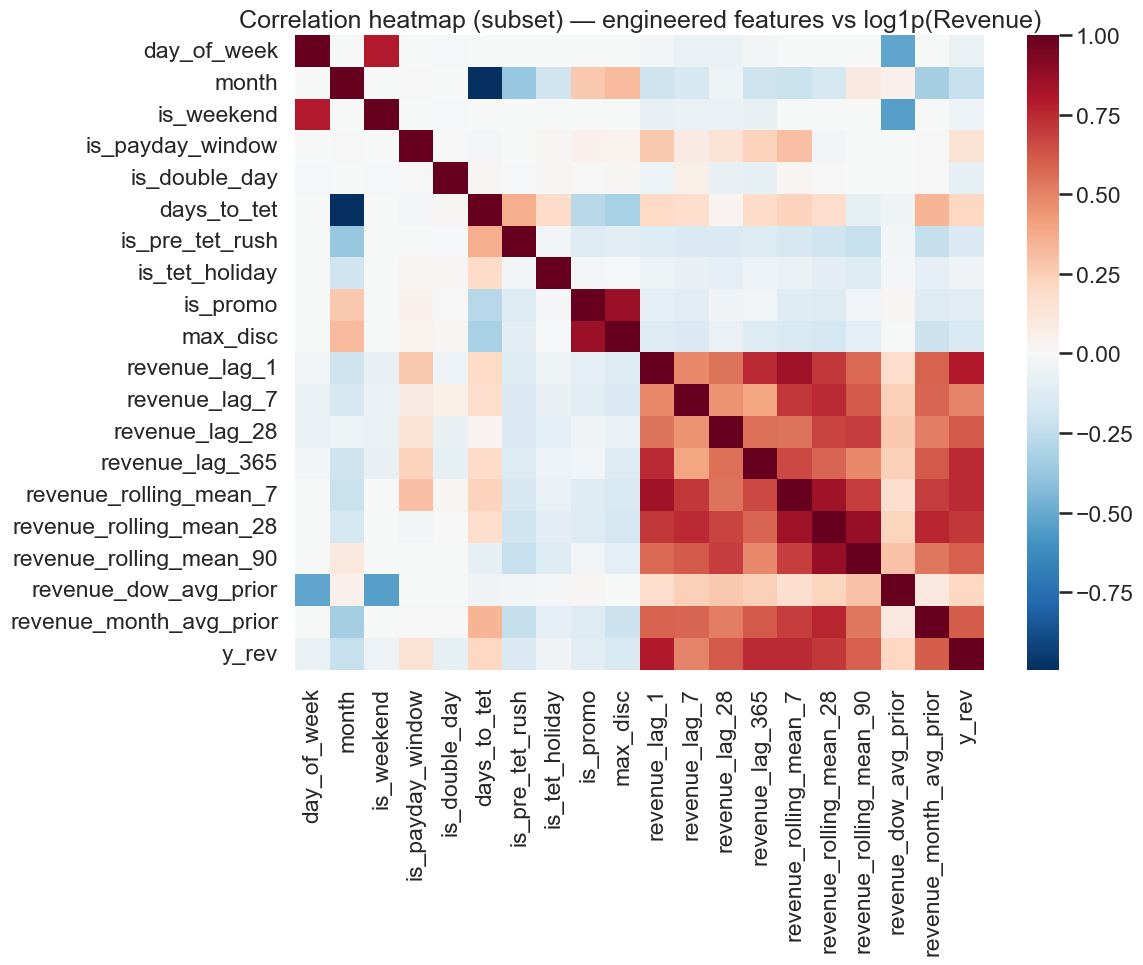

In [14]:
# Visualize correlations for the subset (heatmap)
heat_corr = train_df_corr[subset_features + ["y_rev"]].corr(numeric_only=True)
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
sns.heatmap(heat_corr, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation heatmap (subset) — engineered features vs log1p(Revenue)")
plt.tight_layout(); plt.show()

Biểu đồ correlation heatmap cho thấy nhiều feature thời gian và lag feature có mức tương quan cao với biến mục tiêu `y_rev`. Các feature rolling mean và lag thường có hệ số tương quan mạnh nhất, chứng tỏ dữ liệu lịch sử mang nhiều thông tin dự báo cho tương lai.

Các feature seasonality như `month`, `day_of_week` hoặc feature liên quan đến holiday cũng có correlation nhất định với doanh thu, cho thấy seasonality thực sự tồn tại trong dữ liệu. Tuy correlation không thể hiện hoàn toàn mức độ quan trọng của feature trong mô hình phi tuyến, nhưng heatmap vẫn là công cụ trực quan hữu ích để đánh giá nhanh chất lượng feature engineering trước khi modeling.

## Ý nghĩa đối với Forecasting Model

Các kết quả phân tích từ biểu đồ cho thấy dữ liệu không phải chuỗi ngẫu nhiên mà có cấu trúc thời gian rõ ràng, bao gồm xu hướng dài hạn, seasonality theo tuần/tháng/năm và ảnh hưởng của các sự kiện đặc biệt như Tết hoặc promotion. Điều này cho thấy mô hình forecasting cần khai thác mạnh các temporal features thay vì chỉ sử dụng dữ liệu doanh thu lịch sử đơn thuần.

Ngoài ra, sự tồn tại của autocorrelation cao ở nhiều lag khác nhau chứng minh rằng các lag features và rolling statistics sẽ đóng vai trò quan trọng trong việc cải thiện khả năng dự báo. Các feature như `lag_7`, `lag_28`, `rolling_28` và `rolling_90` có khả năng giúp mô hình học được cả biến động ngắn hạn lẫn xu hướng dài hạn của dữ liệu.

Bên cạnh đó, các seasonal patterns theo tháng và dịp lễ cho thấy việc bổ sung holiday features và cyclical encoding là cần thiết để mô hình phản ánh đúng hành vi tiêu dùng trong các giai đoạn cao điểm mua sắm.